In [1]:
# Cell 1 — project path setup

import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [7]:
import sys 
!{sys.executable} -m pip install tensorflow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Cell 2 — imports

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from src.loaders import load_function
from src.utils import get_best_point, get_top_points, format_query

In [11]:
# Cell 3 — choose the week

week_num = 15
data_root = Path(rf"D:\Capstone_BBO\data\week_{week_num}")

print(rf"Working on Week {week_num}")
print("Data folder:", data_root.resolve())

Working on Week 15
Data folder: D:\Capstone_BBO\data\week_15


In [12]:
# Cell 4 — load all 8 functions automatically

functions_data = {}

for fn in range(1, 9):
    function_folder = data_root / f"function_{fn}"
    inputs_path = function_folder / "initial_inputs.npy"
    outputs_path = function_folder / "initial_outputs.npy"

    X, y = load_function(inputs_path, outputs_path)

    functions_data[fn] = {
        "folder": function_folder,
        "inputs_path": inputs_path,
        "outputs_path": outputs_path,
        "X": X,
        "y": y
    }

print("Loaded functions:", list(functions_data.keys()))

Loaded functions: [1, 2, 3, 4, 5, 6, 7, 8]


In [13]:
# Cell 5 — quick overview of all functions

overview_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    overview_rows.append({
        "function": fn,
        "n_points": X.shape[0],
        "dimension": X.shape[1],
        "y_min": float(np.min(y)),
        "y_max": float(np.max(y)),
        "y_mean": float(np.mean(y)),
        "y_std": float(np.std(y))
    })

overview_df = pd.DataFrame(overview_rows)
overview_df

,function,n_points,dimension,y_min,y_max,y_mean,y_std
0,1,13,2,-0.003606,7.710875e-16,-0.000277,0.000961
1,2,13,2,-0.065624,6.655822e-01,0.273828,0.267402
2,3,18,3,-0.398926,-3.483531e-02,-0.096811,0.080313
3,4,33,4,-32.625660,-2.334948e+00,-15.980207,7.788559
4,5,23,4,0.112940,2.771796e+03,349.162801,626.878813
5,6,23,5,-2.571170,-7.063869e-01,-1.398523,0.487859
6,7,33,6,0.002701,1.402672e+00,0.325611,0.442013
7,8,43,8,5.592193,9.598482e+00,7.938975,1.018874


In [14]:
# Cell 6 — best point for each function

best_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    best_idx, best_x, best_y = get_best_point(X, y)

    best_rows.append({
        "function": fn,
        "best_index": int(best_idx),
        "best_output": float(best_y),
        "best_point": best_x,
        "formatted_best_point": format_query(best_x)
    })

best_df = pd.DataFrame(best_rows)
best_df

,function,best_index,best_output,best_point,formatted_best_point
0,1,2,7.710875e-16,"[0.7310236309563586, 0.7329998764152272]",0.731024-0.733000
1,2,11,6.655822e-01,"[0.702637, 0.940484]",0.702637-0.940484
2,3,3,-3.483531e-02,"[0.49258141463713434, 0.6115931882759961, 0.34...",0.492581-0.611593-0.340176
3,4,32,-2.334948e+00,"[0.468003, 0.383414, 0.266356, 0.376073]",0.468003-0.383414-0.266356-0.376073
4,5,22,2.771796e+03,"[0.8001, 0.522596, 0.993826, 0.999829]",0.800100-0.522596-0.993826-0.999829
5,6,20,-7.063869e-01,"[0.728186, 0.154693, 0.732552, 0.693997, 0.056...",0.728186-0.154693-0.732552-0.693997-0.056401
6,7,31,1.402672e+00,"[0.057896, 0.487666, 0.247422, 0.218118, 0.420...",0.057896-0.487666-0.247422-0.218118-0.420428-0...
7,8,40,9.598482e+00,"[0.056447, 0.065956, 0.022929, 0.038786, 0.403...",0.056447-0.065956-0.022929-0.038786-0.403935-0...


In [15]:
# Cell 7 — top 5 points for a chosen function

# This lets you inspect one function in detail without changing paths.
inspect_function = 3

X = functions_data[inspect_function]["X"]
y = functions_data[inspect_function]["y"]

top_idx, top_X, top_y = get_top_points(X, y, top_n=5)

col_names = [f"x{i+1}" for i in range(X.shape[1])]
top_df = pd.DataFrame(top_X, columns=col_names)
top_df["y"] = top_y
top_df["original_index"] = top_idx

print(f"Top 5 points for Function {inspect_function}")
top_df

Top 5 points for Function 3


,x1,x2,x3,y,original_index
0,0.492581,0.611593,0.340176,-0.034835,3
1,0.600097,0.725136,0.066089,-0.036378,13
2,0.492581,0.590954,0.340176,-0.039700,16
3,0.492581,0.611593,0.340176,-0.043951,15
4,0.220549,0.297825,0.343555,-0.046947,10


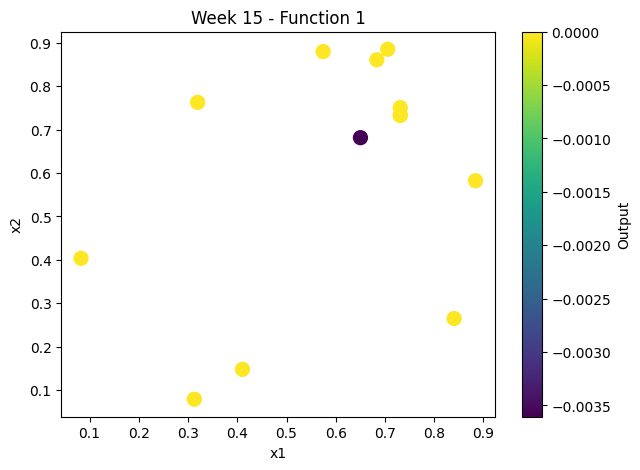

In [16]:
#Cell 9 — create initial candidate table

# This gives you a starting point for all 8 functions.

# For now, the initial candidate is just the current best point. Later we will improve this.

inspect_function = 1

X = functions_data[inspect_function]["X"]
y = functions_data[inspect_function]["y"]

if X.shape[1] == 2:
    plt.figure(figsize=(7,5))
    sc = plt.scatter(X[:, 0], X[:, 1], c=y, s=100)
    plt.colorbar(sc, label="Output")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Week {week_num} - Function {inspect_function}")
    plt.show()
else:
    print(f"Function {inspect_function} is {X.shape[1]}D, so no simple 2D scatter plot.")

In [17]:
def train_nn_surrogate(X, y, epochs=200, batch_size=4, verbose=0):
    """
    Train a small neural-network surrogate model for regression.
    """
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)

    model = keras.Sequential([
        layers.Input(shape=(X.shape[1],)),
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="mse"
    )

    history = model.fit(
        X, y,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose
    )

    return model, history


def generate_nn_candidate(X, y, n_random=3000, random_state=42):
    """
    Fit a small neural network surrogate and use it to rank random
    candidate points in [0,1]^d by predicted output.
    """
    rng = np.random.default_rng(random_state)
    dim = X.shape[1]

    nn_model, history = train_nn_surrogate(X, y, epochs=200, batch_size=4, verbose=0)

    X_search = rng.uniform(0, 1, size=(n_random, dim))
    preds = nn_model.predict(X_search, verbose=0).flatten()

    best_idx = np.argmax(preds)
    best_candidate = X_search[best_idx]

    return best_candidate, nn_model, history, X_search, preds

In [18]:
manual_candidates = {
    1: None,
    2: None,
    3: None,
    4: None,
    5: None,
    6: None,
    7: None,
    8: None
}

In [19]:
def generate_gp_candidate(X, y, n_random=3000, beta=2.0, random_state=42):
    """
    Fit a Gaussian Process and choose a candidate using
    an Upper Confidence Bound (UCB) acquisition rule.

    score = mean + beta * std
    """
    rng = np.random.default_rng(random_state)
    dim = X.shape[1]

    # Candidate search points sampled in [0, 1]^dim
    X_search = rng.uniform(0, 1, size=(n_random, dim))

    # GP model
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(dim), length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-8,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=random_state
    )

    gp.fit(X, y)
    mu, std = gp.predict(X_search, return_std=True)

    ucb = mu + beta * std
    order = np.argsort(ucb)[::-1]

    for idx in order:
        candidate = X_search[idx]
        already_exists = np.any(np.all(np.isclose(X, candidate, atol=1e-6), axis=1))
        if not already_exists:
            return candidate, gp, X_search, mu, std, ucb

    return X_search[order[0]], gp, X_search, mu, std, ucb

In [20]:
np.random.seed(42)

auto_candidates = {}
candidate_method = {}
nn_models = {}
nn_histories = {}

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]
    dim = X.shape[1]

    # Use GP-based BO for lower-dimensional functions
    if dim <= 4:
        candidate, gp_model, X_search, mu, std, ucb = generate_gp_candidate(
            X, y, n_random=3000, beta=2.0, random_state=42 + fn
        )
        auto_candidates[fn] = candidate
        candidate_method[fn] = "GP_UCB"

    # Use NN surrogate for higher-dimensional functions
    else:
        candidate, nn_model, history, X_search, preds = generate_nn_candidate(
            X, y, n_random=3000, random_state=100 + fn
        )
        auto_candidates[fn] = candidate
        candidate_method[fn] = "NN_surrogate"
        nn_models[fn] = nn_model
        nn_histories[fn] = history

auto_candidates

d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarnin

d:\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


{1: array([0.76633698, 0.38484977]),
 2: array([0.74397754, 0.15005444]),
 3: array([0.04927011, 0.15067147, 0.00020022]),
 4: array([0.3254956 , 0.40238549, 0.47779818, 0.45360157]),
 5: array([0.98659128, 0.86608788, 0.97881073, 0.9973734 ]),
 6: array([0.24576855, 0.52912313, 0.4385203 , 0.89784956, 0.01507729]),
 7: array([0.02954011, 0.69603801, 0.98681306, 0.07826937, 0.18942051,
        0.82496715]),
 8: array([0.14239176, 0.10685268, 0.00423423, 0.99684964, 0.72158343,
        0.67535962, 0.02311015, 0.29332788])}

In [21]:
inspect_nn_function = 5

if inspect_nn_function in nn_histories:
    plt.figure(figsize=(7,4))
    plt.plot(nn_histories[inspect_nn_function].history["loss"])
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"NN Training Loss - Function {inspect_nn_function}")
    plt.show()
else:
    print(f"Function {inspect_nn_function} is not using the NN surrogate.")

Function 5 is not using the NN surrogate.


In [22]:
inspect_nn_function = 5

if inspect_nn_function in auto_candidates:
    print("Method:", candidate_method[inspect_nn_function])
    print("Suggested candidate:", auto_candidates[inspect_nn_function])
    print("Formatted query:", format_query(auto_candidates[inspect_nn_function]))
else:
    print("No candidate found.")

Method: GP_UCB
Suggested candidate: [0.98659128 0.86608788 0.97881073 0.9973734 ]
Formatted query: 0.986591-0.866088-0.978811-0.997373


In [23]:
submission_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    best_idx, best_x, best_y = get_best_point(X, y)

    chosen_candidate = manual_candidates.get(fn)
    if chosen_candidate is None:
        chosen_candidate = auto_candidates[fn]

    chosen_candidate = np.array(chosen_candidate, dtype=float)
    chosen_candidate = np.clip(chosen_candidate, 0, 1)

    already_exists = np.any(np.all(np.isclose(X, chosen_candidate, atol=1e-12), axis=1))

    submission_rows.append({
        "function": fn,
        "dimension": X.shape[1],
        "method": candidate_method.get(fn, "Manual"),
        "best_output_so_far": float(best_y),
        "best_point_so_far": format_query(best_x),
        "chosen_candidate_array": chosen_candidate,
        "query": format_query(chosen_candidate),
        "already_exists": bool(already_exists)
    })

submission_df = pd.DataFrame(submission_rows)
submission_df

,function,dimension,method,best_output_so_far,best_point_so_far,chosen_candidate_array,query,already_exists
0,1,2,GP_UCB,7.710875e-16,0.731024-0.733000,"[0.7663369790853671, 0.38484977293095934]",0.766337-0.384850,False
1,2,2,GP_UCB,6.655822e-01,0.702637-0.940484,"[0.7439775356669663, 0.15005444336194118]",0.743978-0.150054,False
2,3,3,GP_UCB,-3.483531e-02,0.492581-0.611593-0.340176,"[0.04927011349196253, 0.1506714682890823, 0.00...",0.049270-0.150671-0.000200,False
3,4,4,GP_UCB,-2.334948e+00,0.468003-0.383414-0.266356-0.376073,"[0.3254955952685702, 0.40238548611411784, 0.47...",0.325496-0.402385-0.477798-0.453602,False
4,5,4,GP_UCB,2.771796e+03,0.800100-0.522596-0.993826-0.999829,"[0.9865912776548658, 0.8660878847845225, 0.978...",0.986591-0.866088-0.978811-0.997373,False
5,6,5,NN_surrogate,-7.063869e-01,0.728186-0.154693-0.732552-0.693997-0.056401,"[0.24576854994795516, 0.5291231269012088, 0.43...",0.245769-0.529123-0.438520-0.897850-0.015077,False
6,7,6,NN_surrogate,1.402672e+00,0.057896-0.487666-0.247422-0.218118-0.420428-0...,"[0.029540105331134048, 0.6960380057806719, 0.9...",0.029540-0.696038-0.986813-0.078269-0.189421-0...,False
7,8,8,NN_surrogate,9.598482e+00,0.056447-0.065956-0.022929-0.038786-0.403935-0...,"[0.14239176491889283, 0.10685268434768136, 0.0...",0.142392-0.106853-0.004234-0.996850-0.721583-0...,False


In [24]:
repeated_df = submission_df[submission_df["already_exists"] == True]
repeated_df

,function,dimension,method,best_output_so_far,best_point_so_far,chosen_candidate_array,query,already_exists


In [25]:
submission_export = submission_df[["function", "query"]].copy()

output_file = Path(rf"D:\Capstone_BBO\submissiones\week_{week_num}_submission.csv")
submission_export.to_csv(output_file, index=False)

print("Saved submission file to:", output_file.resolve())
submission_export

Saved submission file to: D:\Capstone_BBO\submissiones\week_15_submission.csv


,function,query
0,1,0.766337-0.384850
1,2,0.743978-0.150054
2,3,0.049270-0.150671-0.000200
3,4,0.325496-0.402385-0.477798-0.453602
4,5,0.986591-0.866088-0.978811-0.997373
5,6,0.245769-0.529123-0.438520-0.897850-0.015077
6,7,0.029540-0.696038-0.986813-0.078269-0.189421-0...
7,8,0.142392-0.106853-0.004234-0.996850-0.721583-0...
